# Evaluation Pipeline 6.8

Pilot-based evaluation: **full real** vs **multiple generated draws** across pilot sizes.

**Flow:** Config → load → **A** MAD panel → **B** W1/KS violins → **C** geometry & sample structure → **D** correlation structure

**Real:** `../pilot_output/processed_train_136_full_model_data_preprocessed.csv` (same feature space as pilot generated)  
**Generated:** `../pilot_output/generated/` (CVAE **1-0.5 / 1-1 / 1-5** × pilot sizes × 30 draws)

**A:** MAD panel — statistics (rows) × family (cols); within each cell: variant (rows) × pilot size (cols)  
**B/C:** violins — one figure per metric; x = pilot size; hue = variant (CVAE1-0.5 / 1-1 / 1-5)  
**C.1 UMAP:** 9 figures = 3 variants × 3 pilot sizes (Draw 1 each)  
**D.1:** 9-panel mean Δρ heatmap — variant (rows) × pilot size (cols), mean over 30 draws  \n**D.3:** 3 violins — median|Δρ|, Frobenius, Mantel r  \n**D.4:** 5 violins — R_global, R_Pos, R_Neg, R_Neu, F_false (corr_5.4 Summary 1)

In [8]:
# Chunk 1 — Setup. Imports and display defaults.

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [62]:
# Chunk 2 — Config. Paths, model families, pilot sizes.

PROJECT_DIR = Path(r"D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 6.8")
REAL_PATH = PROJECT_DIR / "pilot_output" / "processed_train_136_full_model_data_preprocessed.csv"
PILOT_GEN_DIR = PROJECT_DIR / "pilot_output" / "generated"

PILOT_SIZES = [100, 150, 200]

# Model families → variant tags (rows within each family's heatmap cell).
# Variants are compared side-by-side (same pilot sizes / draws per variant).
MODEL_FAMILIES: dict[str, list[str]] = {
    "CVAEs": ["CVAE1-0.5", "CVAE1-1", "CVAE1-5"],
    # "FLOWs": ["RealNVP", "GLOW", "MAF"],
    # "GANs": ["GAN", "WGAN", "WGAN-GP"],
}

SUMMARY_STATS = {
    "mean": lambda s: float(s.mean()),
    "sd": lambda s: float(s.std(ddof=1)),
    "skewness": lambda s: float(s.skew()),
    "kurtosis": lambda s: float(s.kurt()),
}

PILOT_FILE_RE = re.compile(
    r"_(?P<variant>[^_]+)_(?P<pilot_size>\d+)_Draw(?P<draw>\d+)_generated\.csv$"
)

# C — geometry & sample structure
K_NEIGHBORS_STRUCTURE = 15
K_CLUSTERS_ARI = 2
UMAP_REPRESENTATIVE_DRAW = 1
RANDOM_STATE_STRUCTURE = 42

print("Real:", REAL_PATH, "exists:", REAL_PATH.exists())
print("Pilot gen dir:", PILOT_GEN_DIR, "exists:", PILOT_GEN_DIR.exists())
print("Pilot sizes:", PILOT_SIZES)
print("Model families:")
for family, variants in MODEL_FAMILIES.items():
    print(f"  {family}: {variants}")

Real: D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 6.8\pilot_output\processed_train_136_full_model_data_preprocessed.csv exists: True
Pilot gen dir: D:\CYX\study\research\li-xuan qin\SyNG-BTS\syng_bts_test\python - 6.8\pilot_output\generated exists: True
Pilot sizes: [100, 150, 200]
Model families:
  CVAEs: ['CVAE1-0.5', 'CVAE1-1', 'CVAE1-5']


In [63]:
# Chunk 3 — Data. Load real once; index pilot generated files by family / variant / size / draw.

LABEL_CANDIDATES = ["groups", "groups2"]


def load_real_df(path: Path) -> pd.DataFrame:
    return pd.read_csv(path)


def extract_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    to_drop = [c for c in LABEL_CANDIDATES if c in df.columns]
    out = df.drop(columns=to_drop, errors="ignore")
    out = out.select_dtypes(include=[np.number]).copy()
    out = out.replace([np.inf, -np.inf], np.nan)
    return out


def load_gen_df(path: Path, column_names: list[str]) -> pd.DataFrame:
    gen_raw = pd.read_csv(path, header=None)
    if gen_raw.shape[1] != len(column_names):
        raise ValueError(
            f"{path.name}: gen has {gen_raw.shape[1]} cols, expected {len(column_names)} (same as real CSV)."
        )
    gen_raw.columns = column_names
    return gen_raw


def load_gen_features(path: Path, column_names: list[str]) -> pd.DataFrame:
    return prepare_features(extract_numeric_features(load_gen_df(path, column_names)))


def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    return df.apply(lambda s: s.fillna(s.median()), axis=0)


def discover_pilot_files(
    gen_dir: Path,
    model_families: dict[str, list[str]],
    pilot_sizes: list[int],
) -> pd.DataFrame:
    """Return registry: family, variant, pilot_size, draw, path."""
    variant_to_family = {
        variant: family
        for family, variants in model_families.items()
        for variant in variants
    }
    rows: list[dict] = []
    for path in sorted(gen_dir.glob("*_generated.csv")):
        m = PILOT_FILE_RE.search(path.name)
        if m is None:
            continue
        variant = m.group("variant")
        if variant not in variant_to_family:
            continue
        pilot_size = int(m.group("pilot_size"))
        if pilot_size not in pilot_sizes:
            continue
        rows.append(
            {
                "family": variant_to_family[variant],
                "variant": variant,
                "pilot_size": pilot_size,
                "draw": int(m.group("draw")),
                "path": path,
            }
        )
    registry = pd.DataFrame(rows)
    if registry.empty:
        raise FileNotFoundError(
            f"No pilot generated files matched MODEL_FAMILIES under {gen_dir}"
        )
    return registry.sort_values(["family", "variant", "pilot_size", "draw"]).reset_index(drop=True)


real_df = load_real_df(REAL_PATH)
gen_column_names = real_df.columns.tolist()

real_x = prepare_features(extract_numeric_features(real_df))
feature_columns = real_x.columns.tolist()

pilot_registry = discover_pilot_files(PILOT_GEN_DIR, MODEL_FAMILIES, PILOT_SIZES)

print(f"Real numeric features: {real_x.shape}")
print(f"Real CSV columns (incl. labels): {len(gen_column_names)}")
print(f"Pilot registry rows: {len(pilot_registry)}")
display(
    pilot_registry.groupby(["family", "variant", "pilot_size"])["draw"]
    .agg(["count", "min", "max"])
    .rename(columns={"count": "n_draws"})
)

_peek = load_gen_features(pilot_registry.iloc[0]["path"], gen_column_names)
print(f"Example gen numeric shape: {_peek.shape}")

# --- Shared violin styling (B / C / D): family colormap + variant hues ---

FAMILY_CMAP: dict[str, str] = {
    "CVAEs": "Blues",
    "FLOWs": "Oranges",
    "GANs": "Greens",
}


def variant_palette(
    model_families: dict[str, list[str]],
    family: str | None = None,
) -> dict[str, tuple]:
    """Light → dark within each model family."""
    out: dict[str, tuple] = {}
    items = (
        {family: model_families[family]}.items()
        if family is not None
        else model_families.items()
    )
    for fam, variants in items:
        n = len(variants)
        if n == 0:
            continue
        colors = sns.color_palette(FAMILY_CMAP.get(fam, "Greys"), n_colors=max(n + 1, 3))[-n:]
        for i, variant in enumerate(variants):
            out[variant] = colors[i]
    return out


def plot_pilot_violin_panel(
    draw_df: pd.DataFrame,
    model_families: dict[str, list[str]],
    pilot_sizes: list[int],
    metric: str,
    title: str,
    ylabel: str,
    section_label: str = "",
) -> None:
    """One figure per metric; columns = families; x = pilot size; dodge = variant."""
    family_names = list(model_families.keys())
    n_families = len(family_names)
    all_variants = [v for variants in model_families.values() for v in variants]
    max_variants = max((len(v) for v in model_families.values()), default=1)

    fig_w = max(4.8 * n_families, 4.5 + 1.1 * max_variants)
    fig, axes = plt.subplots(1, n_families, figsize=(fig_w, 5.0), squeeze=False)
    legend_handles = None
    legend_labels = None

    for j, family in enumerate(family_names):
        ax = axes[0, j]
        variants = model_families[family]
        sub = draw_df[
            (draw_df["family"] == family) & (draw_df["variant"].isin(variants))
        ].copy()
        sub["pilot_size"] = pd.Categorical(sub["pilot_size"], categories=pilot_sizes, ordered=True)

        palette = variant_palette(model_families, family=family)
        hue = "variant" if len(variants) > 1 else None
        sns.violinplot(
            data=sub,
            x="pilot_size",
            y=metric,
            hue=hue,
            hue_order=variants if hue else None,
            order=pilot_sizes,
            palette=palette if hue else None,
            dodge=True if hue else False,
            inner="box",
            cut=0,
            linewidth=0.8,
            density_norm="width",
            ax=ax,
        )
        if hue is not None and legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(family, fontsize=12, pad=8)
        ax.set_xlabel("Pilot size")
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.grid(True, axis="y", alpha=0.3)

    if legend_handles and legend_labels:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Models",
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=min(len(all_variants), 6),
            frameon=False,
        )

    fig.suptitle(title, y=1.02, fontsize=13)
    if section_label:
        fig.text(
            0.01, 0.98, section_label,
            transform=fig.transFigure, fontsize=16, fontweight="bold", va="top",
        )
    bottom = 0.12 if len(all_variants) <= 1 else (0.24 if len(all_variants) >= 3 else 0.22)
    fig.subplots_adjust(bottom=bottom)
    plt.tight_layout()
    plt.show()

Real numeric features: (604, 135)
Real CSV columns (incl. labels): 136
Pilot registry rows: 270


n_draws  min  max
family variant   pilot_size                   
CVAEs  CVAE1-0.5 100              30    1   30
                 150              30    1   30
                 200              30    1   30
       CVAE1-1   100              30    1   30
                 150              30    1   30
                 200              30    1   30
       CVAE1-5   100              30    1   30
                 150              30    1   30
                 200              30    1   30

Example gen numeric shape: (1000, 135)


In [64]:
# Chunk 4 — A.1 Per draw: real vs gen → absolute MAD vector (4 statistics).


def mad_1d(values: np.ndarray) -> float:
    v = np.asarray(values, dtype=float)
    med = np.median(v)
    return float(np.median(np.abs(v - med)))


def absolute_mad_by_statistic(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> dict[str, float]:
    common_cols = [c for c in real_x.columns if c in gen_x.columns]
    if not common_cols:
        raise ValueError("No common features between real and generated data.")
    out: dict[str, float] = {}
    for stat_name, fn in SUMMARY_STATS.items():
        abs_diffs = []
        for feat in common_cols:
            rv = fn(real_x[feat])
            gv = fn(gen_x[feat])
            abs_diffs.append(abs(rv - gv))
        out[stat_name] = mad_1d(np.asarray(abs_diffs, dtype=float))
    return out


mad_draw_records: list[dict] = []
for row in pilot_registry.itertuples(index=False):
    gen_x = load_gen_features(row.path, gen_column_names)
    mad_map = absolute_mad_by_statistic(real_x, gen_x)
    for stat_name, mad_val in mad_map.items():
        mad_draw_records.append(
            {
                "family": row.family,
                "variant": row.variant,
                "pilot_size": row.pilot_size,
                "draw": row.draw,
                "statistic": stat_name,
                "mad": mad_val,
            }
        )

mad_draw_df = pd.DataFrame(mad_draw_records)

mad_mean_df = (
    mad_draw_df.groupby(["family", "variant", "pilot_size", "statistic"], as_index=False)["mad"]
    .mean()
    .rename(columns={"mad": "mad_mean"})
)

print(f"Computed MAD for {mad_draw_df['draw'].nunique()} draws × {len(SUMMARY_STATS)} statistics.")
display(mad_mean_df.head(8))

Computed MAD for 30 draws × 4 statistics.


,family,variant,pilot_size,statistic,mad_mean
0,CVAEs,CVAE1-0.5,100,kurtosis,0.204838
1,CVAEs,CVAE1-0.5,100,mean,0.023286
2,CVAEs,CVAE1-0.5,100,sd,0.055229
3,CVAEs,CVAE1-0.5,100,skewness,0.059039
4,CVAEs,CVAE1-0.5,150,kurtosis,0.208583
5,CVAEs,CVAE1-0.5,150,mean,0.018500
6,CVAEs,CVAE1-0.5,150,sd,0.060874
7,CVAEs,CVAE1-0.5,150,skewness,0.057908


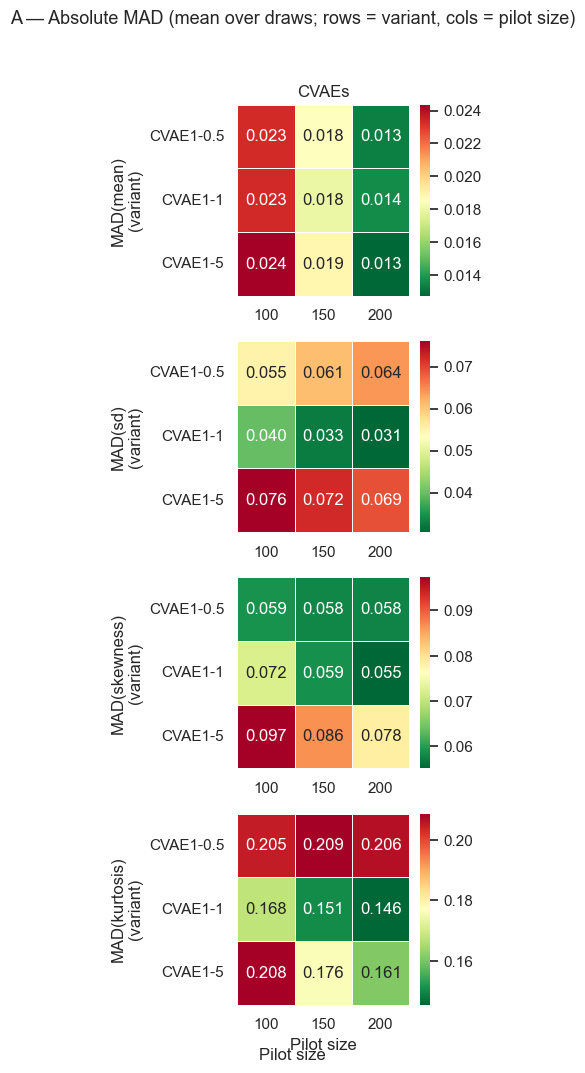

In [65]:
# Chunk 5 — A.2 Panel heatmaps: statistics (rows) × families (cols); each cell = variant × pilot_size.


def build_family_stat_matrix(
    mad_mean_df: pd.DataFrame,
    family: str,
    statistic: str,
    variants: list[str],
    pilot_sizes: list[int],
) -> pd.DataFrame:
    sub = mad_mean_df[(mad_mean_df["family"] == family) & (mad_mean_df["statistic"] == statistic)]
    mat = (
        sub.pivot(index="variant", columns="pilot_size", values="mad_mean")
        .reindex(index=variants, columns=pilot_sizes)
    )
    return mat


def plot_mad_panel_a(
    mad_mean_df: pd.DataFrame,
    model_families: dict[str, list[str]],
    pilot_sizes: list[int],
    summary_stats: dict[str, object],
    cmap: str = "RdYlGn_r",  # low MAD → green (good); high → yellow/red (paper style)
    annot_fmt: str = ".3f",
) -> None:
    stat_names = list(summary_stats.keys())
    family_names = list(model_families.keys())
    n_stats = len(stat_names)
    n_families = len(family_names)
    max_variants = max(len(v) for v in model_families.values())

    fig_w = max(3.2 * n_families, 4.0)
    fig_h = max(2.6 * n_stats, 1.8 * max_variants + 2.5)
    fig, axes = plt.subplots(n_stats, n_families, figsize=(fig_w, fig_h), squeeze=False)

    for i, stat in enumerate(stat_names):
        row_mats = [
            build_family_stat_matrix(
                mad_mean_df, family, stat, model_families[family], pilot_sizes
            )
            for family in family_names
        ]
        vals = np.concatenate([m.to_numpy(dtype=float).ravel() for m in row_mats])
        vals = vals[np.isfinite(vals)]
        vmin = float(np.min(vals)) if vals.size else 0.0
        vmax = float(np.max(vals)) if vals.size else 1.0
        if vmin == vmax:
            vmax = vmin + 1e-6

        for j, family in enumerate(family_names):
            ax = axes[i, j]
            mat = row_mats[j]
            sns.heatmap(
                mat,
                annot=True,
                fmt=annot_fmt,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                cbar=(j == n_families - 1),
                linewidths=0.5,
                linecolor="white",
                ax=ax,
            )
            ax.set_xlabel("Pilot size" if i == n_stats - 1 else "")
            if i == 0:
                ax.set_title(family)
            if j == 0:
                ax.tick_params(axis="y", labelleft=True)
                n_var = len(model_families[family])
                ax.set_ylabel(
                    f"MAD({stat})\n(variant)" if n_var > 1 else f"MAD({stat})"
                )
            else:
                ax.set_ylabel("")
                ax.set_yticklabels([])

    fig.suptitle(
        "A — Absolute MAD (mean over draws; rows = variant, cols = pilot size)",
        y=1.02,
        fontsize=13,
    )
    fig.text(0.5, 0.01, "Pilot size", ha="center")
    plt.tight_layout()
    plt.show()


plot_mad_panel_a(mad_mean_df, MODEL_FAMILIES, PILOT_SIZES, SUMMARY_STATS)

In [66]:
# Chunk 6 — B.1 Per draw: real vs gen → median W1 / median KS across features.

from scipy.stats import ks_2samp, wasserstein_distance

MARGINAL_METRICS = ("W1_median", "KS_median")


def median_w1_ks(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> dict[str, float]:
    """Per-feature W1 and KS; return median across features (one replicate per draw)."""
    common_cols = [c for c in real_x.columns if c in gen_x.columns]
    if not common_cols:
        raise ValueError("No common features between real and generated data.")

    w1_vals: list[float] = []
    ks_vals: list[float] = []
    for feat in common_cols:
        r_col = real_x[feat].to_numpy(dtype=float)
        g_col = gen_x[feat].to_numpy(dtype=float)
        w1_vals.append(float(wasserstein_distance(r_col, g_col)))
        ks_vals.append(
            float(ks_2samp(r_col, g_col, alternative="two-sided", method="asymp").statistic)
        )

    return {
        "W1_median": float(np.median(w1_vals)),
        "KS_median": float(np.median(ks_vals)),
    }


marginal_draw_records: list[dict] = []
for row in pilot_registry.itertuples(index=False):
    gen_x = load_gen_features(row.path, gen_column_names)
    scores = median_w1_ks(real_x, gen_x)
    marginal_draw_records.append(
        {
            "family": row.family,
            "variant": row.variant,
            "pilot_size": row.pilot_size,
            "draw": row.draw,
            **scores,
        }
    )

marginal_draw_df = pd.DataFrame(marginal_draw_records)

print(f"Marginal metrics computed for {len(marginal_draw_df)} draws.")
display(
    marginal_draw_df.groupby(["variant", "pilot_size"])[list(MARGINAL_METRICS)]
    .agg(["median", "mean", "std", "count"])
)

Marginal metrics computed for 270 draws.


W1_median                           KS_median                          
                        median      mean       std count    median      mean       std count
variant   pilot_size                                                                        
CVAE1-0.5 100         0.261796  0.263823  0.012336    30  0.125477  0.126689  0.007328    30
          150         0.263988  0.265517  0.010904    30  0.124695  0.125034  0.006010    30
          200         0.256105  0.255528  0.011357    30  0.118123  0.118676  0.006194    30
CVAE1-1   100         0.141857  0.141702  0.013427    30  0.072424  0.076163  0.008945    30
          150         0.109838  0.112465  0.011035    30  0.062576  0.063499  0.005213    30
          200         0.096056  0.096504  0.008255    30  0.056050  0.055732  0.003918    30
CVAE1-5   100         0.191495  0.196090  0.030107    30  0.099632  0.102295  0.013889    30
          150         0.163190  0.165839  0.025796    30  0.086308  0.089893  0.012112    30
          200         0.147579  0.150008  0.013832    30  0.079043  0.079289  0.005358    30

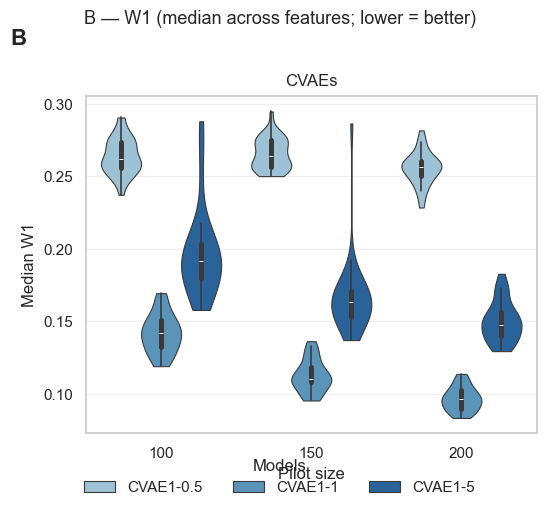

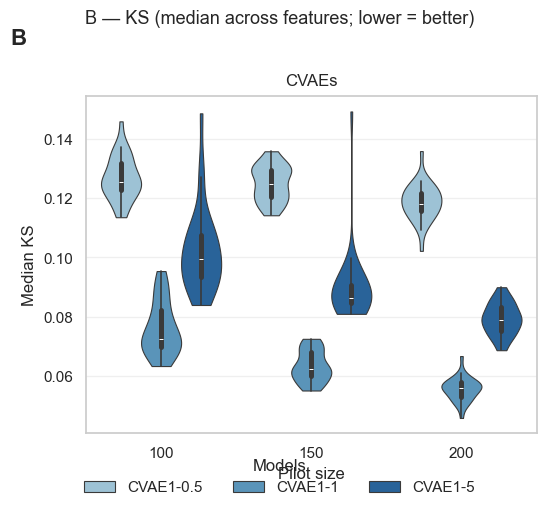

In [67]:
# Chunk 7 — B.2 Violin plots: one figure per metric (W1 / KS); x = pilot size; hue = variant.

MARGINAL_PLOT_SPECS = {
    "W1_median": {
        "title": "B — W1 (median across features; lower = better)",
        "ylabel": "Median W1",
    },
    "KS_median": {
        "title": "B — KS (median across features; lower = better)",
        "ylabel": "Median KS",
    },
}

for metric, spec in MARGINAL_PLOT_SPECS.items():
    plot_pilot_violin_panel(
        marginal_draw_df,
        MODEL_FAMILIES,
        PILOT_SIZES,
        metric=metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        section_label="B",
    )

In [74]:
# Chunk 8 — C.0 Shared helpers for sample-structure metrics (kNN / silhouette / ARI).

from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


def _effective_k(n_points: int, k: int) -> int:
    return max(2, min(k, n_points - 1))


def stack_and_scale(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Stack real+gen, StandardScaler. Returns Xs, y_is_real (1=real), y_source (0=real, 1=gen)."""
    common_cols = [c for c in real_x.columns if c in gen_x.columns]
    real_arr = real_x[common_cols].to_numpy(dtype=float)
    gen_arr = gen_x[common_cols].to_numpy(dtype=float)
    n_real = real_arr.shape[0]
    X = np.vstack([real_arr, gen_arr])
    y_is_real = np.array([1] * n_real + [0] * gen_arr.shape[0], dtype=np.int32)
    y_source = np.array([0] * n_real + [1] * gen_arr.shape[0], dtype=np.int32)
    Xs = StandardScaler().fit_transform(X)
    return Xs, y_is_real, y_source


def knn_mixing_score(X: np.ndarray, y_is_real: np.ndarray, k: int) -> float:
    """Higher => local real/gen mix closer to global mix."""
    k_use = _effective_k(X.shape[0], k)
    p_global = float(np.mean(y_is_real))
    nn = NearestNeighbors(n_neighbors=k_use + 1, algorithm="auto")
    nn.fit(X)
    _, inds = nn.kneighbors(X)
    neigh = inds[:, 1 : k_use + 1]
    p_local = np.mean(y_is_real[neigh], axis=1)
    return float(1.0 - np.mean(np.abs(p_local - p_global)))


def compute_knn_mixing(real_x: pd.DataFrame, gen_x: pd.DataFrame, k: int) -> float:
    Xs, y_is_real, _ = stack_and_scale(real_x, gen_x)
    return knn_mixing_score(Xs, y_is_real, k)


def compute_silhouette(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> float:
    Xs, y_is_real, _ = stack_and_scale(real_x, gen_x)
    try:
        return float(silhouette_score(Xs, y_is_real, metric="euclidean"))
    except ValueError:
        return float("nan")


def compute_ari_cari(
    real_x: pd.DataFrame,
    gen_x: pd.DataFrame,
    k_clusters: int,
    random_state: int,
) -> tuple[float, float]:
    Xs, _, y_source = stack_and_scale(real_x, gen_x)
    try:
        km = KMeans(n_clusters=k_clusters, n_init=10, random_state=random_state)
        y_cluster = km.fit_predict(Xs)
        ari = float(adjusted_rand_score(y_source, y_cluster))
    except ValueError:
        ari = float("nan")
    return ari, float(1.0 - ari)


# --- Plotting helpers (mirror Chunk 3; keep C runnable after Chunk 3 data load) ---

FAMILY_CMAP: dict[str, str] = {
    "CVAEs": "Blues",
    "FLOWs": "Oranges",
    "GANs": "Greens",
}


def variant_palette(
    model_families: dict[str, list[str]],
    family: str | None = None,
) -> dict[str, tuple]:
    """Light → dark within each model family."""
    out: dict[str, tuple] = {}
    items = (
        {family: model_families[family]}.items()
        if family is not None
        else model_families.items()
    )
    for fam, variants in items:
        n = len(variants)
        if n == 0:
            continue
        colors = sns.color_palette(FAMILY_CMAP.get(fam, "Greys"), n_colors=max(n + 1, 3))[-n:]
        for i, variant in enumerate(variants):
            out[variant] = colors[i]
    return out


def plot_pilot_violin_panel(
    draw_df: pd.DataFrame,
    model_families: dict[str, list[str]],
    pilot_sizes: list[int],
    metric: str,
    title: str,
    ylabel: str,
    section_label: str = "",
) -> None:
    """One figure per metric; columns = families; x = pilot size; dodge = variant."""
    family_names = list(model_families.keys())
    n_families = len(family_names)
    all_variants = [v for variants in model_families.values() for v in variants]
    max_variants = max((len(v) for v in model_families.values()), default=1)

    fig_w = max(4.8 * n_families, 4.5 + 1.1 * max_variants)
    fig, axes = plt.subplots(1, n_families, figsize=(fig_w, 5.0), squeeze=False)
    legend_handles = None
    legend_labels = None

    for j, family in enumerate(family_names):
        ax = axes[0, j]
        variants = model_families[family]
        sub = draw_df[
            (draw_df["family"] == family) & (draw_df["variant"].isin(variants))
        ].copy()
        sub["pilot_size"] = pd.Categorical(sub["pilot_size"], categories=pilot_sizes, ordered=True)

        palette = variant_palette(model_families, family=family)
        hue = "variant" if len(variants) > 1 else None
        sns.violinplot(
            data=sub,
            x="pilot_size",
            y=metric,
            hue=hue,
            hue_order=variants if hue else None,
            order=pilot_sizes,
            palette=palette if hue else None,
            dodge=True if hue else False,
            inner="box",
            cut=0,
            linewidth=0.8,
            density_norm="width",
            ax=ax,
        )
        if hue is not None and legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(family, fontsize=12, pad=8)
        ax.set_xlabel("Pilot size")
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.grid(True, axis="y", alpha=0.3)

    if legend_handles and legend_labels:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Models",
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=min(len(all_variants), 6),
            frameon=False,
        )

    fig.suptitle(title, y=1.02, fontsize=13)
    if section_label:
        fig.text(
            0.01, 0.98, section_label,
            transform=fig.transFigure, fontsize=16, fontweight="bold", va="top",
        )
    bottom = 0.12 if len(all_variants) <= 1 else (0.24 if len(all_variants) >= 3 else 0.22)
    fig.subplots_adjust(bottom=bottom)
    plt.tight_layout()
    plt.show()

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


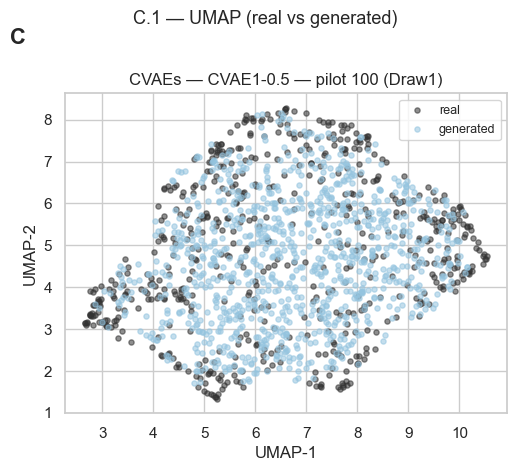

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


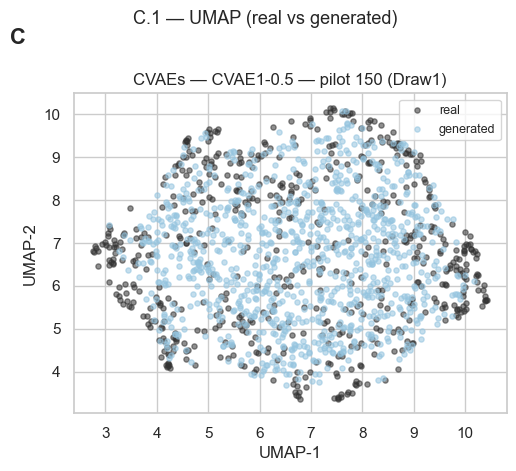

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


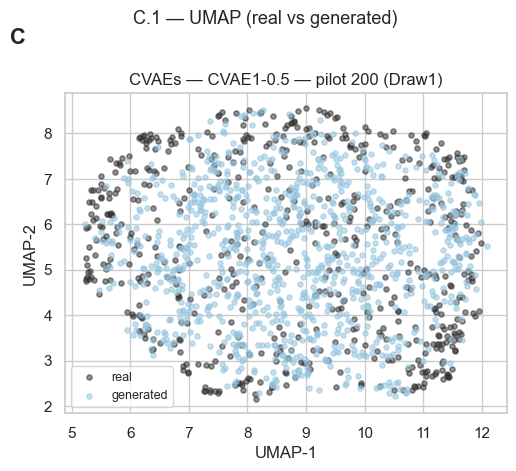

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


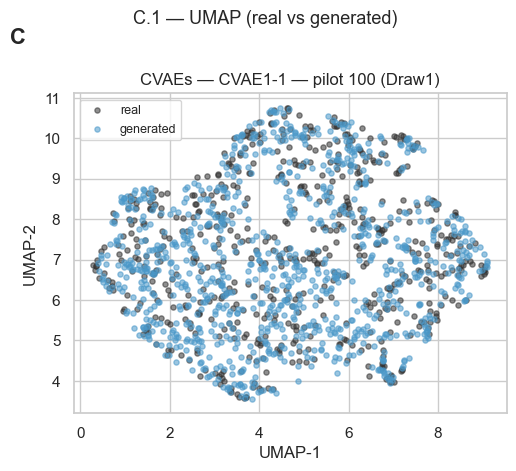

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


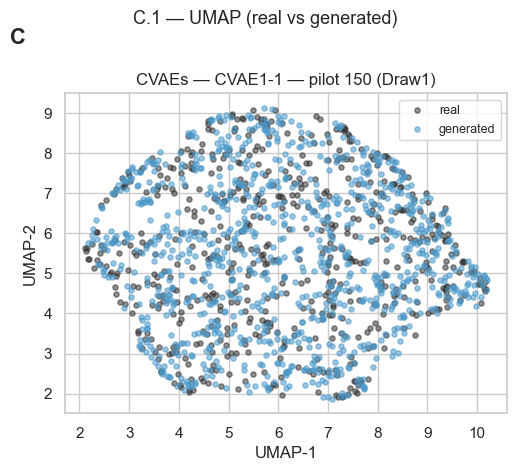

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


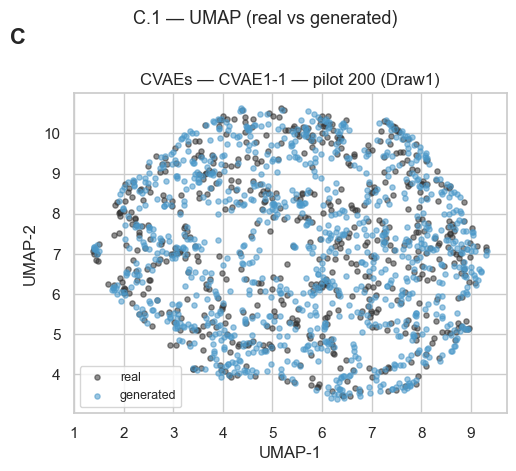

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


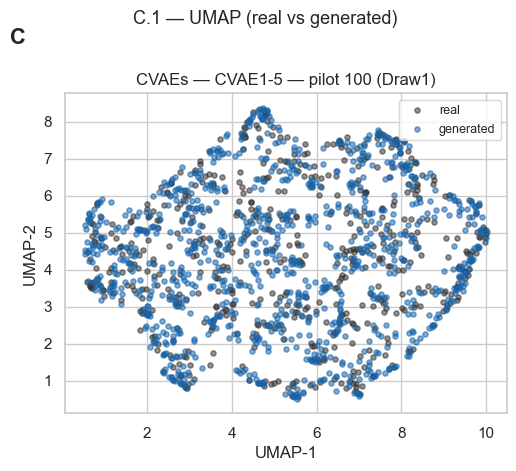

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


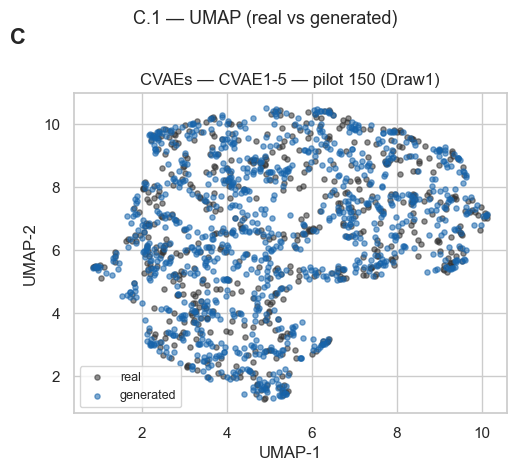

c:\Users\17376\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\17376\AppData\Local\Temp\ipykernel_31164\3115414704.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)


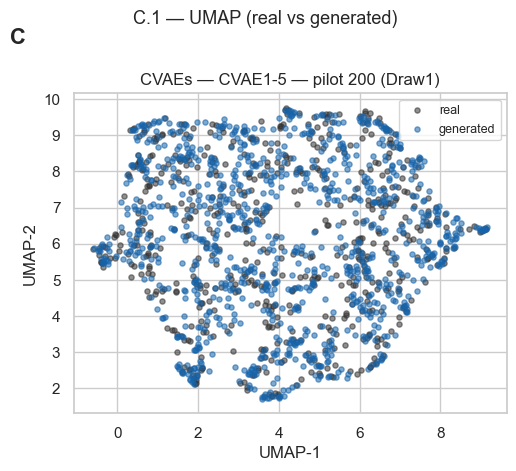

UMAP figures plotted: 9 (expected 9)


In [75]:
# Chunk 9 — C.1 UMAP. One figure per (variant, pilot size), Draw 1 → 3 variants × 3 sizes.

from sklearn.preprocessing import StandardScaler

try:
    import umap  # type: ignore

    HAS_UMAP = True
except Exception as exc:
    HAS_UMAP = False
    print("UMAP not available:", repr(exc))


def fit_umap_2d(real_x: pd.DataFrame, gen_x: pd.DataFrame, random_state: int = 42) -> tuple[np.ndarray, np.ndarray]:
    common_cols = [c for c in real_x.columns if c in gen_x.columns]
    X = np.vstack([real_x[common_cols].to_numpy(float), gen_x[common_cols].to_numpy(float)])
    n_real = len(real_x)
    Xs = StandardScaler().fit_transform(X)
    n_nb = min(15, max(2, Xs.shape[0] - 1))
    reducer = umap.UMAP(n_components=2, random_state=random_state, n_neighbors=n_nb, min_dist=0.1)
    Z = reducer.fit_transform(Xs)
    return Z[:n_real], Z[n_real:]


def plot_umap_figure(
    z_real: np.ndarray,
    z_gen: np.ndarray,
    variant: str,
    pilot_size: int,
    draw: int,
    family: str,
    gen_color: str | tuple = "#2171b5",
) -> None:
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    ax.scatter(z_real[:, 0], z_real[:, 1], alpha=0.55, s=14, label="real", c="#333333", rasterized=True)
    ax.scatter(z_gen[:, 0], z_gen[:, 1], alpha=0.55, s=14, label="generated", c=gen_color, rasterized=True)
    ax.legend(loc="best", fontsize=9)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_title(f"{family} — {variant} — pilot {pilot_size} (Draw{draw})")
    fig.text(0.01, 0.98, "C", transform=fig.transFigure, fontsize=16, fontweight="bold", va="top")
    fig.suptitle("C.1 — UMAP (real vs generated)", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


UMAP_DRAW = 1
_variant_colors = variant_palette(MODEL_FAMILIES)

if HAS_UMAP:
    n_expected = sum(len(v) for v in MODEL_FAMILIES.values()) * len(PILOT_SIZES)
    n_plotted = 0
    for family, variants in MODEL_FAMILIES.items():
        for variant in variants:
            for pilot_size in PILOT_SIZES:
                sub = pilot_registry[
                    (pilot_registry["family"] == family)
                    & (pilot_registry["variant"] == variant)
                    & (pilot_registry["pilot_size"] == pilot_size)
                    & (pilot_registry["draw"] == UMAP_DRAW)
                ]
                if sub.empty:
                    print(f"Skip UMAP: {variant} pilot={pilot_size} Draw{UMAP_DRAW} (no file)")
                    continue
                gen_x = load_gen_features(sub.iloc[0]["path"], gen_column_names)
                zr, zg = fit_umap_2d(real_x, gen_x, random_state=RANDOM_STATE_STRUCTURE)
                plot_umap_figure(
                    zr, zg, variant, pilot_size, UMAP_DRAW, family,
                    gen_color=_variant_colors.get(variant, "#2171b5"),
                )
                n_plotted += 1
    print(f"UMAP figures plotted: {n_plotted} (expected {n_expected})")
else:
    print("Skip UMAP plots.")

C.2 — kNN mixing (higher = better mix)


median      mean       std  count
variant   pilot_size                                     
CVAE1-0.5 100         0.795764  0.795501  0.007518     30
          150         0.807304  0.806756  0.008866     30
          200         0.817978  0.816330  0.005897     30
CVAE1-1   100         0.755729  0.755783  0.018351     30
          150         0.778012  0.774087  0.015893     30
          200         0.789708  0.788164  0.013997     30
CVAE1-5   100         0.679480  0.680200  0.003363     30
          150         0.677107  0.677290  0.002632     30
          200         0.675495  0.676110  0.002891     30

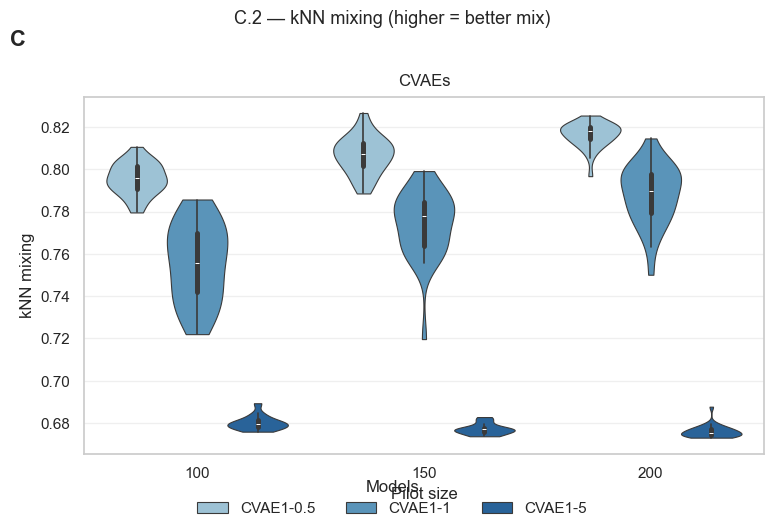

In [76]:
# Chunk 10 — C.2 kNN mixing. Per draw → violin by pilot size.

knn_draw_records: list[dict] = []
for row in pilot_registry.itertuples(index=False):
    gen_x = load_gen_features(row.path, gen_column_names)
    knn_draw_records.append(
        {
            "family": row.family,
            "variant": row.variant,
            "pilot_size": row.pilot_size,
            "draw": row.draw,
            "knn_mixing": compute_knn_mixing(real_x, gen_x, K_NEIGHBORS_STRUCTURE),
        }
    )

knn_draw_df = pd.DataFrame(knn_draw_records)

print("C.2 — kNN mixing (higher = better mix)")
display(
    knn_draw_df.groupby(["variant", "pilot_size"])["knn_mixing"]
    .agg(["median", "mean", "std", "count"])
)

plot_pilot_violin_panel(
    knn_draw_df,
    MODEL_FAMILIES,
    PILOT_SIZES,
    metric="knn_mixing",
    title="C.2 — kNN mixing (higher = better mix)",
    ylabel="kNN mixing",
    section_label="C",
)

C.3 — Silhouette (lower / near 0 = harder to separate real vs gen)


median      mean       std  count
variant   pilot_size                                     
CVAE1-0.5 100         0.058874  0.058556  0.003701     30
          150         0.056683  0.056591  0.003792     30
          200         0.051626  0.051770  0.003136     30
CVAE1-1   100         0.029752  0.030344  0.004228     30
          150         0.023081  0.023665  0.002981     30
          200         0.019870  0.020041  0.001801     30
CVAE1-5   100         0.059933  0.063384  0.011100     30
          150         0.054170  0.056098  0.010675     30
          200         0.050998  0.050776  0.004476     30

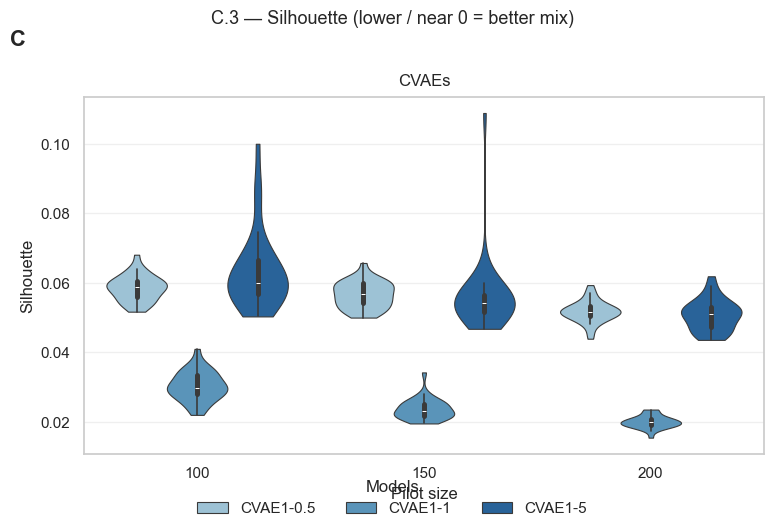

In [77]:
# Chunk 11 — C.3 Silhouette. Per draw → violin by pilot size (lower / near 0 = better mix).

silhouette_draw_records: list[dict] = []
for row in pilot_registry.itertuples(index=False):
    gen_x = load_gen_features(row.path, gen_column_names)
    silhouette_draw_records.append(
        {
            "family": row.family,
            "variant": row.variant,
            "pilot_size": row.pilot_size,
            "draw": row.draw,
            "silhouette": compute_silhouette(real_x, gen_x),
        }
    )

silhouette_draw_df = pd.DataFrame(silhouette_draw_records)

print("C.3 — Silhouette (lower / near 0 = harder to separate real vs gen)")
display(
    silhouette_draw_df.groupby(["variant", "pilot_size"])["silhouette"]
    .agg(["median", "mean", "std", "count"])
)

plot_pilot_violin_panel(
    silhouette_draw_df,
    MODEL_FAMILIES,
    PILOT_SIZES,
    metric="silhouette",
    title="C.3 — Silhouette (lower / near 0 = better mix)",
    ylabel="Silhouette",
    section_label="C",
)

c:\Users\17376\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(
c:\Users\17376\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

C.4 — ARI (lower = clusters do not recover real/synthetic source)


median      mean       std  count
variant   pilot_size                                     
CVAE1-0.5 100         0.000031  0.000319  0.001895     30
          150        -0.000016  0.001396  0.003584     30
          200         0.000473  0.001859  0.003527     30
CVAE1-1   100        -0.000819 -0.000480  0.001461     30
          150        -0.000771 -0.000200  0.002136     30
          200        -0.000744 -0.000644  0.001069     30
CVAE1-5   100        -0.000695 -0.000198  0.002377     30
          150        -0.000069  0.000149  0.002051     30
          200        -0.000300 -0.000027  0.001272     30

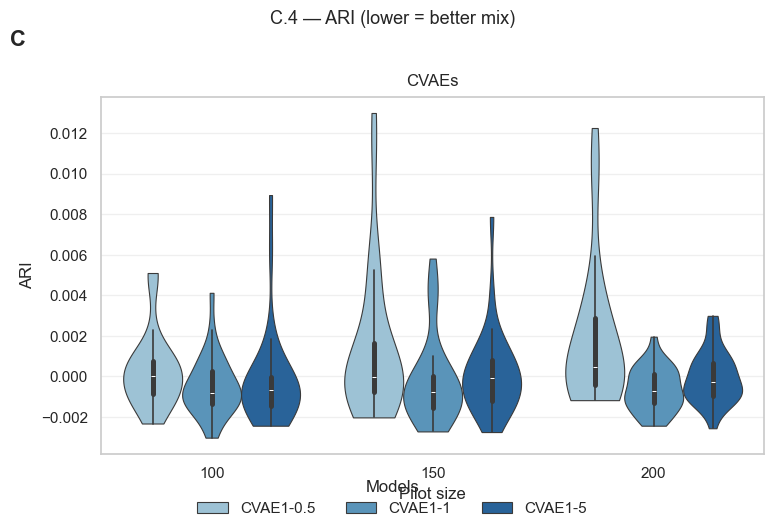

In [78]:
# Chunk 12 — C.4 ARI. Per draw: KMeans(k=2) vs source labels → violin (lower = better mix).

ari_draw_records: list[dict] = []
for row in pilot_registry.itertuples(index=False):
    gen_x = load_gen_features(row.path, gen_column_names)
    ari, cari = compute_ari_cari(
        real_x,
        gen_x,
        k_clusters=K_CLUSTERS_ARI,
        random_state=RANDOM_STATE_STRUCTURE + row.draw,
    )
    ari_draw_records.append(
        {
            "family": row.family,
            "variant": row.variant,
            "pilot_size": row.pilot_size,
            "draw": row.draw,
            "ari": ari,
            "cari": cari,
        }
    )

ari_draw_df = pd.DataFrame(ari_draw_records)

print("C.4 — ARI (lower = clusters do not recover real/synthetic source)")
display(
    ari_draw_df.groupby(["variant", "pilot_size"])["ari"]
    .agg(["median", "mean", "std", "count"])
)

plot_pilot_violin_panel(
    ari_draw_df,
    MODEL_FAMILIES,
    PILOT_SIZES,
    metric="ari",
    title="C.4 — ARI (lower = better mix)",
    ylabel="ARI",
    section_label="C",
)

C.5 — cARI = 1 − ARI (higher = better mix)


median      mean       std  count
variant   pilot_size                                     
CVAE1-0.5 100         0.999969  0.999681  0.001895     30
          150         1.000016  0.998604  0.003584     30
          200         0.999527  0.998141  0.003527     30
CVAE1-1   100         1.000819  1.000480  0.001461     30
          150         1.000771  1.000200  0.002136     30
          200         1.000744  1.000644  0.001069     30
CVAE1-5   100         1.000695  1.000198  0.002377     30
          150         1.000069  0.999851  0.002051     30
          200         1.000300  1.000027  0.001272     30

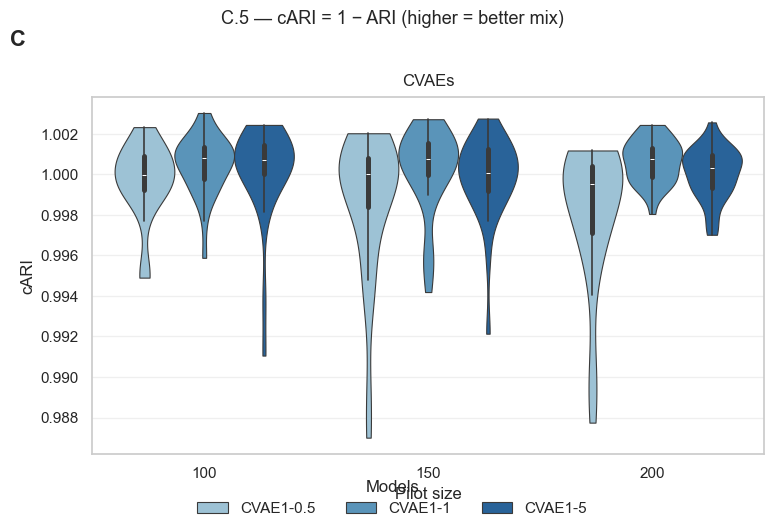

In [79]:
# Chunk 13 — C.5 cARI (= 1 − ARI). Same draws as Chunk 12; higher = better mix.

print("C.5 — cARI = 1 − ARI (higher = better mix)")
display(
    ari_draw_df.groupby(["variant", "pilot_size"])["cari"]
    .agg(["median", "mean", "std", "count"])
)

plot_pilot_violin_panel(
    ari_draw_df,
    MODEL_FAMILIES,
    PILOT_SIZES,
    metric="cari",
    title="C.5 — cARI = 1 − ARI (higher = better mix)",
    ylabel="cARI",
    section_label="C",
)

In [80]:
# Chunk 14 — D.0 Correlation helpers.


def corr_matrix_from_samples(X: np.ndarray) -> np.ndarray:
    """Pearson correlation across columns; rows are observations."""
    C = np.corrcoef(X, rowvar=False)
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)


def corr_structure_scalars(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> dict[str, float]:
    """ΔR = R_real − R_gen → median|Δρ|, Frobenius, Mantel r."""
    cols = [c for c in real_x.columns if c in gen_x.columns]
    Cr = corr_matrix_from_samples(real_x[cols].to_numpy(dtype=float))
    Cg = corr_matrix_from_samples(gen_x[cols].to_numpy(dtype=float))
    dR = Cr - Cg
    p = Cr.shape[0]
    mask = ~np.eye(p, dtype=bool)
    med_abs = float(np.median(np.abs(dR[mask])))
    frob = float(np.linalg.norm(dR, ord="fro"))
    iu = np.triu_indices(p, k=1)
    vr = Cr[iu]
    vg = Cg[iu]
    if np.std(vr) < 1e-12 or np.std(vg) < 1e-12:
        mantel = float("nan")
    else:
        mantel = float(np.corrcoef(vr, vg)[0, 1])
    return {
        "median_abs_delta_rho": med_abs,
        "frobenius_delta_R": frob,
        "mantel_corr": mantel,
    }


def delta_corr_matrix(real_x: pd.DataFrame, gen_x: pd.DataFrame) -> np.ndarray:
    cols = [c for c in real_x.columns if c in gen_x.columns]
    Cr = corr_matrix_from_samples(real_x[cols].to_numpy(dtype=float))
    Cg = corr_matrix_from_samples(gen_x[cols].to_numpy(dtype=float))
    return Cr - Cg


def mean_delta_corr_matrix(real_x: pd.DataFrame, gen_frames: list[pd.DataFrame]) -> np.ndarray:
    """Element-wise mean of Δρ = R_real − R_gen over multiple generated draws."""
    if not gen_frames:
        raise ValueError("gen_frames must contain at least one generated dataset.")
    diffs = [delta_corr_matrix(real_x, gen_x) for gen_x in gen_frames]
    return np.mean(np.stack(diffs, axis=0), axis=0)


def plot_corr_diff_matrix(
    diff: np.ndarray,
    ax,
    title: str,
    vmax: float | None,
) -> float:
    if vmax is None:
        v = float(np.quantile(np.abs(diff), 0.99)) if diff.size else 1.0
        v = max(v, 1e-6)
    else:
        v = max(float(vmax), 1e-6)
    sns.heatmap(
        diff,
        cmap="coolwarm",
        center=0.0,
        vmin=-v,
        vmax=v,
        ax=ax,
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar_kws={"shrink": 0.75},
    )
    ax.set_title(title)
    ax.set_xlabel("feature")
    ax.set_ylabel("feature")
    return v


def plot_corr_diff_heatmap(
    real_x: pd.DataFrame,
    gen_x: pd.DataFrame,
    ax,
    title: str,
    vmax: float | None,
) -> float:
    return plot_corr_diff_matrix(delta_corr_matrix(real_x, gen_x), ax, title, vmax)


# --- Summary 1 (corr_5.4): Pearson label agreement on real-defined Pos/Neg/Neu pairs ---

RHO_THRESH = 0.3  # Neutral iff |r| <= tau; labels fixed on full real only


def _upper_tri_rho(C: np.ndarray) -> np.ndarray:
    iu = np.triu_indices(C.shape[0], k=1)
    return C[iu]


def _labels_from_rho(rho: np.ndarray, tau: float) -> np.ndarray:
    return np.where(
        rho > tau,
        "Positive",
        np.where(rho < -tau, "Negative", "Neutral"),
    )


def build_real_pairwise_labels(real_x: pd.DataFrame, tau: float = RHO_THRESH) -> dict:
    """Real-only Pearson labels for all unordered feature pairs (upper triangle)."""
    cols = [c for c in real_x.columns]
    Cr = corr_matrix_from_samples(real_x[cols].to_numpy(dtype=float))
    rho_real = _upper_tri_rho(Cr)
    label_real = _labels_from_rho(rho_real, tau)
    return {"rho_real": rho_real, "label_real": label_real, "tau": tau}


def summary1_scalars(
    rho_syn: np.ndarray,
    rho_real: np.ndarray,
    label_real: np.ndarray,
    tau: float,
) -> dict[str, float]:
    """Global and stratified agreement + false-correlation rate (corr_5.4 Summary 1)."""
    label_syn = _labels_from_rho(rho_syn, tau)
    neutral_real = label_real == "Neutral"
    same_sign = np.sign(rho_real) == np.sign(rho_syn)
    same_label = label_real == label_syn
    agree = np.where(
        neutral_real,
        np.abs(rho_syn) <= tau,
        (~neutral_real) & same_label & same_sign,
    )
    out: dict[str, float] = {"R_global": float(agree.mean())}
    for k, sym in [("Positive", "R_Pos"), ("Negative", "R_Neg"), ("Neutral", "R_Neu")]:
        m = label_real == k
        out[sym] = float(agree[m].mean()) if m.any() else float("nan")
    m_neu = label_real == "Neutral"
    n_neu = int(m_neu.sum())
    out["F_false"] = (
        float(((np.abs(rho_syn) > tau) & m_neu).sum() / n_neu) if n_neu else float("nan")
    )
    return out


def summary1_from_frames(
    real_x: pd.DataFrame,
    gen_x: pd.DataFrame,
    real_pairwise: dict,
) -> dict[str, float]:
    cols = [c for c in real_x.columns if c in gen_x.columns]
    Cg = corr_matrix_from_samples(gen_x[cols].to_numpy(dtype=float))
    rho_syn = _upper_tri_rho(Cg)
    return summary1_scalars(
        rho_syn,
        real_pairwise["rho_real"],
        real_pairwise["label_real"],
        real_pairwise["tau"],
    )


# --- Plotting helpers (mirror Chunk 3 / C.0; keep D runnable after Chunk 3 data load) ---

FAMILY_CMAP: dict[str, str] = {
    "CVAEs": "Blues",
    "FLOWs": "Oranges",
    "GANs": "Greens",
}


def variant_palette(
    model_families: dict[str, list[str]],
    family: str | None = None,
) -> dict[str, tuple]:
    """Light → dark within each model family."""
    out: dict[str, tuple] = {}
    items = (
        {family: model_families[family]}.items()
        if family is not None
        else model_families.items()
    )
    for fam, variants in items:
        n = len(variants)
        if n == 0:
            continue
        colors = sns.color_palette(FAMILY_CMAP.get(fam, "Greys"), n_colors=max(n + 1, 3))[-n:]
        for i, variant in enumerate(variants):
            out[variant] = colors[i]
    return out


def plot_pilot_violin_panel(
    draw_df: pd.DataFrame,
    model_families: dict[str, list[str]],
    pilot_sizes: list[int],
    metric: str,
    title: str,
    ylabel: str,
    section_label: str = "",
) -> None:
    """One figure per metric; columns = families; x = pilot size; dodge = variant."""
    family_names = list(model_families.keys())
    n_families = len(family_names)
    all_variants = [v for variants in model_families.values() for v in variants]
    max_variants = max((len(v) for v in model_families.values()), default=1)

    fig_w = max(4.8 * n_families, 4.5 + 1.1 * max_variants)
    fig, axes = plt.subplots(1, n_families, figsize=(fig_w, 5.0), squeeze=False)
    legend_handles = None
    legend_labels = None

    for j, family in enumerate(family_names):
        ax = axes[0, j]
        variants = model_families[family]
        sub = draw_df[
            (draw_df["family"] == family) & (draw_df["variant"].isin(variants))
        ].copy()
        sub["pilot_size"] = pd.Categorical(sub["pilot_size"], categories=pilot_sizes, ordered=True)

        palette = variant_palette(model_families, family=family)
        hue = "variant" if len(variants) > 1 else None
        sns.violinplot(
            data=sub,
            x="pilot_size",
            y=metric,
            hue=hue,
            hue_order=variants if hue else None,
            order=pilot_sizes,
            palette=palette if hue else None,
            dodge=True if hue else False,
            inner="box",
            cut=0,
            linewidth=0.8,
            density_norm="width",
            ax=ax,
        )
        if hue is not None and legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(family, fontsize=12, pad=8)
        ax.set_xlabel("Pilot size")
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.grid(True, axis="y", alpha=0.3)

    if legend_handles and legend_labels:
        fig.legend(
            legend_handles,
            legend_labels,
            title="Models",
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=min(len(all_variants), 6),
            frameon=False,
        )

    fig.suptitle(title, y=1.02, fontsize=13)
    if section_label:
        fig.text(
            0.01, 0.98, section_label,
            transform=fig.transFigure, fontsize=16, fontweight="bold", va="top",
        )
    bottom = 0.12 if len(all_variants) <= 1 else (0.24 if len(all_variants) >= 3 else 0.22)
    fig.subplots_adjust(bottom=bottom)
    plt.tight_layout()
    plt.show()

[CVAE1-0.5 pilot=100] mean Δρ over 30 draws
[CVAE1-0.5 pilot=150] mean Δρ over 30 draws
[CVAE1-0.5 pilot=200] mean Δρ over 30 draws
[CVAE1-1 pilot=100] mean Δρ over 30 draws
[CVAE1-1 pilot=150] mean Δρ over 30 draws
[CVAE1-1 pilot=200] mean Δρ over 30 draws
[CVAE1-5 pilot=100] mean Δρ over 30 draws
[CVAE1-5 pilot=150] mean Δρ over 30 draws
[CVAE1-5 pilot=200] mean Δρ over 30 draws


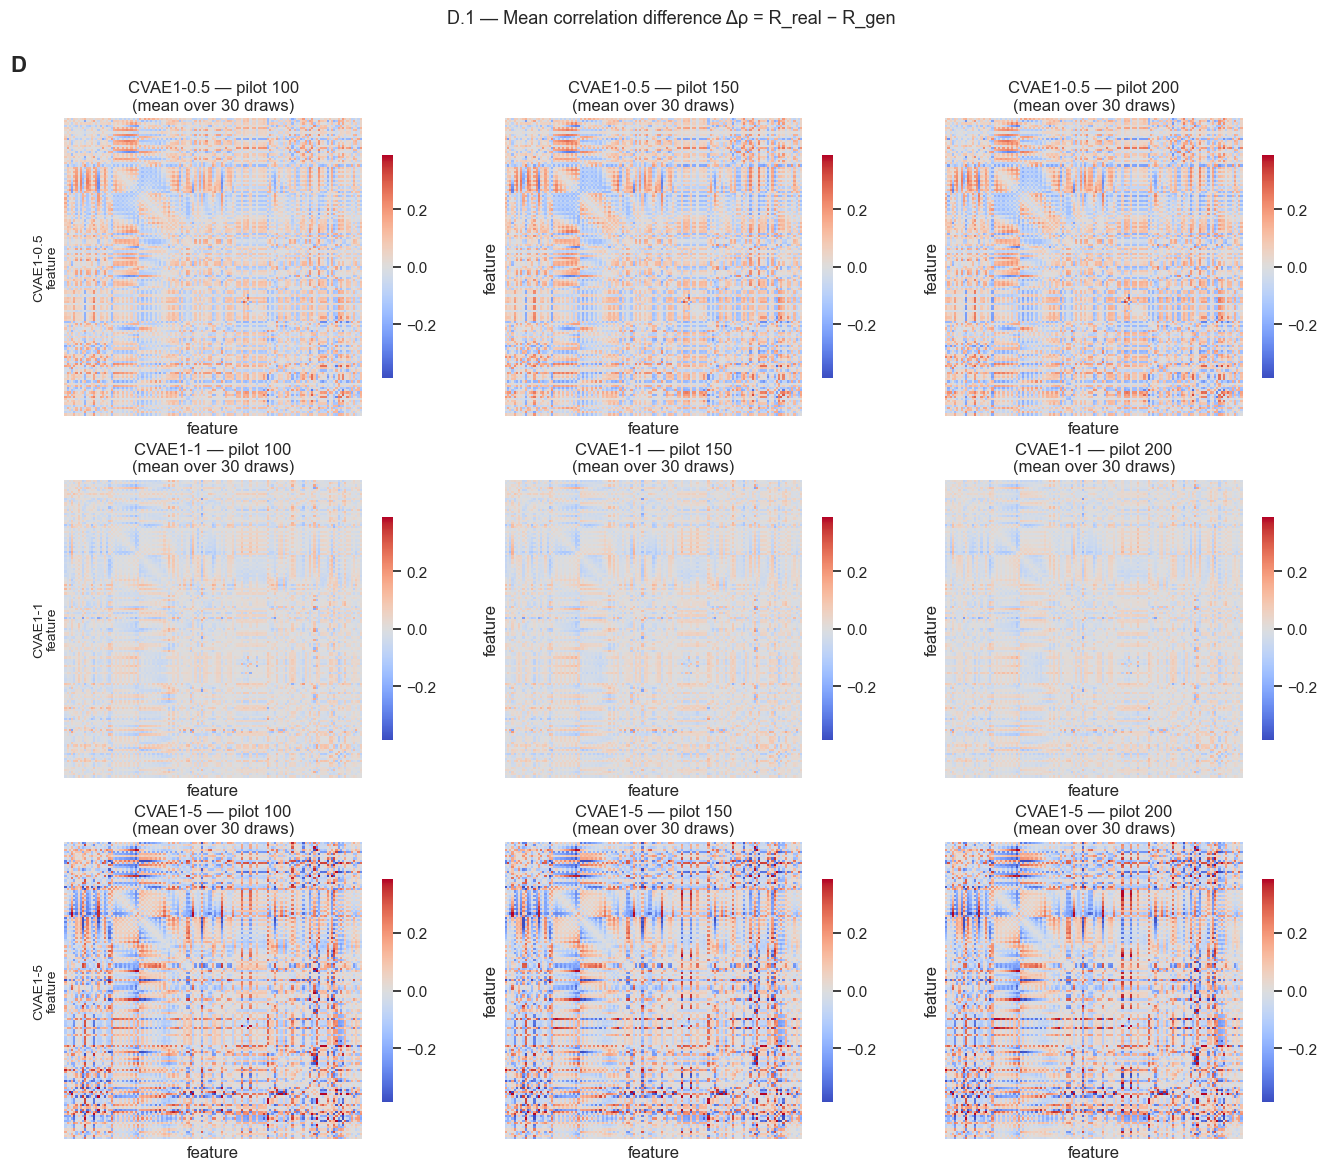

In [81]:
# Chunk 15 — D.1 Mean Δρ heatmaps. Element-wise mean over all draws; rows = variant, cols = pilot size.

variant_rows: list[tuple[str, str]] = [
    (family, variant)
    for family, variants in MODEL_FAMILIES.items()
    for variant in variants
]
n_var_rows = len(variant_rows)
n_sizes = len(PILOT_SIZES)

mean_diff_by_cell: dict[tuple[str, str, int], np.ndarray] = {}
draw_count_by_cell: dict[tuple[str, str, int], int] = {}
vmax_shared = 0.0

for family, variant in variant_rows:
    for pilot_size in PILOT_SIZES:
        sub = pilot_registry[
            (pilot_registry["family"] == family)
            & (pilot_registry["variant"] == variant)
            & (pilot_registry["pilot_size"] == pilot_size)
        ]
        if sub.empty:
            continue
        gen_frames = [
            load_gen_features(row.path, gen_column_names)
            for row in sub.itertuples(index=False)
        ]
        mean_diff = mean_delta_corr_matrix(real_x, gen_frames)
        key = (family, variant, pilot_size)
        mean_diff_by_cell[key] = mean_diff
        draw_count_by_cell[key] = len(gen_frames)
        vmax_shared = max(
            vmax_shared,
            float(np.quantile(np.abs(mean_diff), 0.99)) if mean_diff.size else 1.0,
        )
        print(f"[{variant} pilot={pilot_size}] mean Δρ over {len(gen_frames)} draws")

vmax_shared = max(vmax_shared, 1e-6)

fig, axes = plt.subplots(
    n_var_rows,
    n_sizes,
    figsize=(max(4.5 * n_sizes, 6.0), max(3.8 * n_var_rows, 4.0)),
    squeeze=False,
)

for i, (family, variant) in enumerate(variant_rows):
    for j, pilot_size in enumerate(PILOT_SIZES):
        ax = axes[i, j]
        key = (family, variant, pilot_size)
        if key not in mean_diff_by_cell:
            ax.set_title(f"{variant} — pilot {pilot_size} (no data)")
            ax.axis("off")
            continue
        n_draws = draw_count_by_cell[key]
        plot_corr_diff_matrix(
            mean_diff_by_cell[key],
            ax,
            f"{variant} — pilot {pilot_size}\n(mean over {n_draws} draws)",
            vmax_shared,
        )
        if j == 0:
            ax.set_ylabel(f"{variant}\nfeature", fontsize=10)

fig.suptitle("D.1 — Mean correlation difference Δρ = R_real − R_gen", y=1.02, fontsize=13)
fig.text(0.01, 0.98, "D", transform=fig.transFigure, fontsize=16, fontweight="bold", va="top")
plt.tight_layout()
plt.show()

In [82]:
# Chunk 16 — D.2 Correlation scalars + D.4 Summary 1 prep. One pass over pilot_registry.

CORR_SCALAR_METRICS = ("median_abs_delta_rho", "frobenius_delta_R", "mantel_corr")
SUMMARY1_METRICS = ("R_global", "R_Pos", "R_Neg", "R_Neu", "F_false")

real_pairwise = build_real_pairwise_labels(real_x, tau=RHO_THRESH)
_lr = real_pairwise["label_real"]
print(
    f"Real pairwise labels (tau={RHO_THRESH}): "
    f"Pos={(_lr == 'Positive').sum()}, Neg={(_lr == 'Negative').sum()}, "
    f"Neu={(_lr == 'Neutral').sum()}, N={len(_lr)}"
)

corr_draw_records: list[dict] = []
summary1_draw_records: list[dict] = []
for row in pilot_registry.itertuples(index=False):
    gen_x = load_gen_features(row.path, gen_column_names)
    corr_draw_records.append(
        {
            "family": row.family,
            "variant": row.variant,
            "pilot_size": row.pilot_size,
            "draw": row.draw,
            **corr_structure_scalars(real_x, gen_x),
        }
    )
    summary1_draw_records.append(
        {
            "family": row.family,
            "variant": row.variant,
            "pilot_size": row.pilot_size,
            "draw": row.draw,
            **summary1_from_frames(real_x, gen_x, real_pairwise),
        }
    )

corr_draw_df = pd.DataFrame(corr_draw_records)
summary1_draw_df = pd.DataFrame(summary1_draw_records)

print(f"D.2 — Correlation scalars computed for {len(corr_draw_df)} draws.")
display(
    corr_draw_df.groupby(["variant", "pilot_size"])[list(CORR_SCALAR_METRICS)]
    .agg(["median", "mean", "std", "count"])
)

print(f"D.4 — Summary 1 scalars computed for {len(summary1_draw_df)} draws.")
display(
    summary1_draw_df.groupby(["variant", "pilot_size"])[list(SUMMARY1_METRICS)]
    .agg(["median", "mean", "std", "count"])
)

Real pairwise labels (tau=0.3): Pos=2436, Neg=1488, Neu=5121, N=9045
D.2 — Correlation scalars computed for 270 draws.


median_abs_delta_rho                           frobenius_delta_R                            mantel_corr                          
                                   median      mean       std count            median       mean       std count      median      mean       std count
variant   pilot_size                                                                                                                                  
CVAE1-0.5 100                    0.073931  0.074709  0.007501    30         14.684418  14.837669  1.373328    30    0.964672  0.963835  0.007389    30
          150                    0.079957  0.079242  0.008740    30         15.650760  15.458400  1.454148    30    0.962042  0.961929  0.008038    30
          200                    0.080096  0.081127  0.007937    30         15.959351  15.805366  1.222489    30    0.959633  0.960219  0.006612    30
CVAE1-1   100                    0.055342  0.055327  0.009050    30         12.017614  12.051486  1.543892    30    0.980454  0.979705  0.005805    30
          150                    0.045786  0.046210  0.006961    30         10.009080  10.051975  1.104772    30    0.986316  0.986074  0.002968    30
          200                    0.039337  0.039756  0.005426    30          8.810722   8.878845  0.789248    30    0.989346  0.989286  0.001830    30
CVAE1-5   100                    0.099433  0.100687  0.015365    30         22.468119  22.605162  2.875320    30    0.955499  0.953957  0.009159    30
          150                    0.084233  0.087879  0.010772    30         20.813937  21.090515  1.850451    30    0.962384  0.960808  0.006436    30
          200                    0.081418  0.081801  0.008242    30         19.883223  20.301963  1.913272    30    0.965901  0.964273  0.006401    30

D.4 — Summary 1 scalars computed for 270 draws.


R_global                               R_Pos                               R_Neg                               R_Neu                             F_false                      \
                        median      mean       std count    median      mean       std count    median      mean       std count    median      mean       std count    median      mean       std   
variant   pilot_size                                                                                                                                                                                 
CVAE1-0.5 100         0.867606  0.862948  0.015349    30  0.773604  0.769787  0.028888    30  0.678091  0.672558  0.050826    30  0.962800  0.962585  0.007903    30  0.037200  0.037415  0.007903   
          150         0.854339  0.853263  0.013323    30  0.745279  0.742789  0.028485    30  0.639785  0.632796  0.039488    30  0.970221  0.969876  0.007691    30  0.029779  0.030124  0.007691   
          200         0.848425  0.849198  0.014599    30  0.735427  0.738164  0.031562    30  0.620968  0.616823  0.042264    30  0.970806  0.969537  0.007959    30  0.029194  0.030463  0.007959   
CVAE1-1   100         0.902764  0.901393  0.013762    30  0.960386  0.958607  0.017431    30  0.935148  0.936671  0.028691    30  0.867799  0.863926  0.026401    30  0.132201  0.136074  0.026401   
          150         0.919071  0.917914  0.010748    30  0.973317  0.970361  0.013465    30  0.950605  0.945632  0.028005    30  0.886057  0.884912  0.018049    30  0.113943  0.115088  0.018049   
          200         0.929464  0.930186  0.007012    30  0.978243  0.978448  0.008992    30  0.965054  0.958333  0.020014    30  0.896993  0.899050  0.014651    30  0.103007  0.100950  0.014651   
CVAE1-5   100         0.827640  0.823671  0.024066    30  0.979885  0.978571  0.008297    30  0.973454  0.971281  0.015008    30  0.709725  0.707095  0.043289    30  0.290275  0.292905  0.043289   
          150         0.840851  0.837634  0.014823    30  0.988095  0.986959  0.005105    30  0.982863  0.980735  0.009444    30  0.731010  0.725021  0.024332    30  0.268990  0.274979  0.024332   
          200         0.847098  0.844861  0.013546    30  0.990558  0.990545  0.003186    30  0.987231  0.982370  0.010814    30  0.739895  0.735605  0.023511    30  0.260105  0.264395  0.023511   

                            
                     count  
variant   pilot_size        
CVAE1-0.5 100           30  
          150           30  
          200           30  
CVAE1-1   100           30  
          150           30  
          200           30  
CVAE1-5   100           30  
          150           30  
          200           30

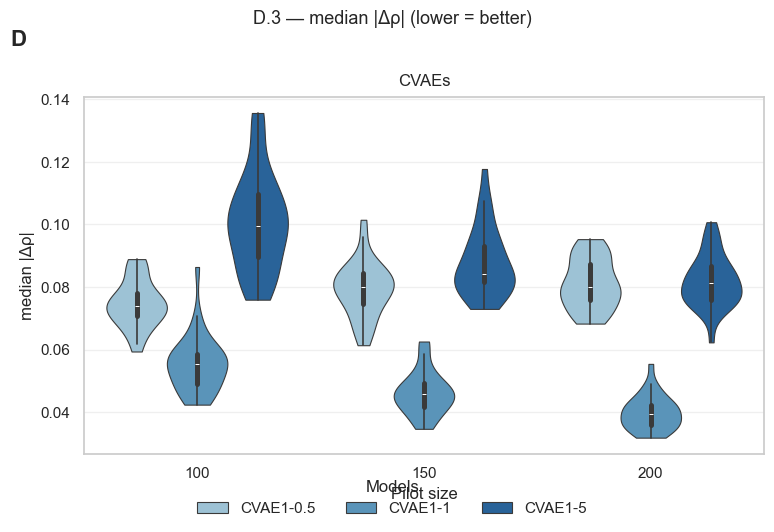

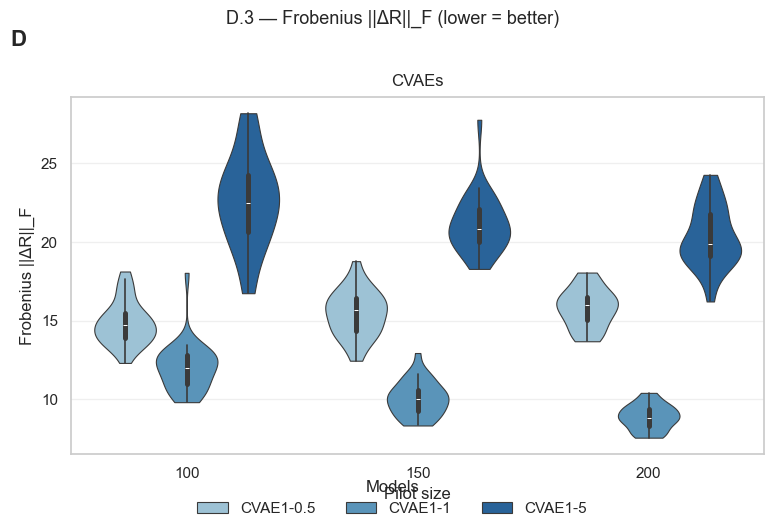

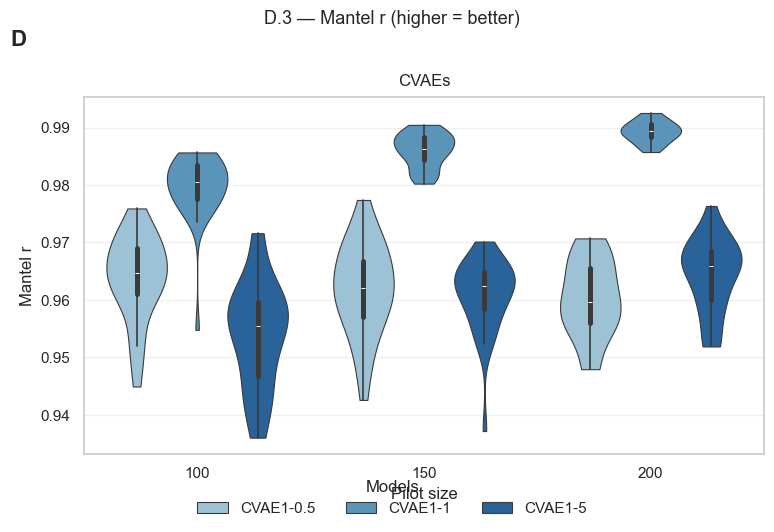

In [83]:
# Chunk 17 — D.3 Violin plots: one figure per correlation scalar; x = pilot size.

CORR_PLOT_SPECS = {
    "median_abs_delta_rho": {
        "title": "D.3 — median |Δρ| (lower = better)",
        "ylabel": "median |Δρ|",
    },
    "frobenius_delta_R": {
        "title": "D.3 — Frobenius ||ΔR||_F (lower = better)",
        "ylabel": "Frobenius ||ΔR||_F",
    },
    "mantel_corr": {
        "title": "D.3 — Mantel r (higher = better)",
        "ylabel": "Mantel r",
    },
}

for metric, spec in CORR_PLOT_SPECS.items():
    plot_pilot_violin_panel(
        corr_draw_df,
        MODEL_FAMILIES,
        PILOT_SIZES,
        metric=metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        section_label="D",
    )

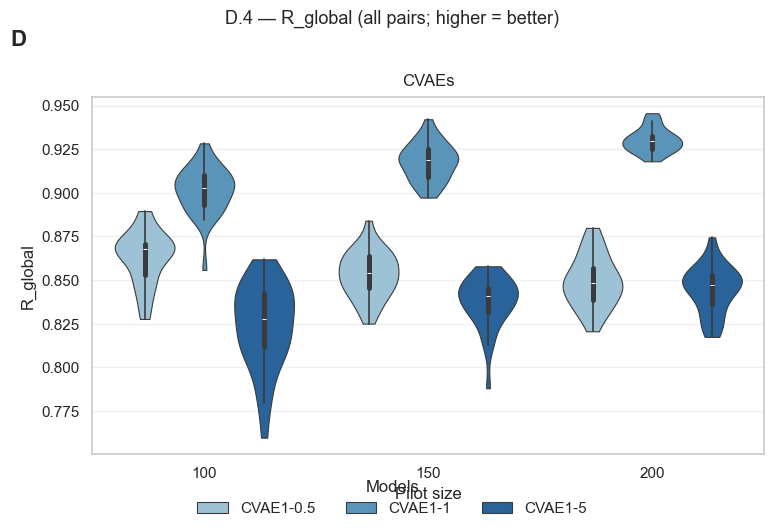

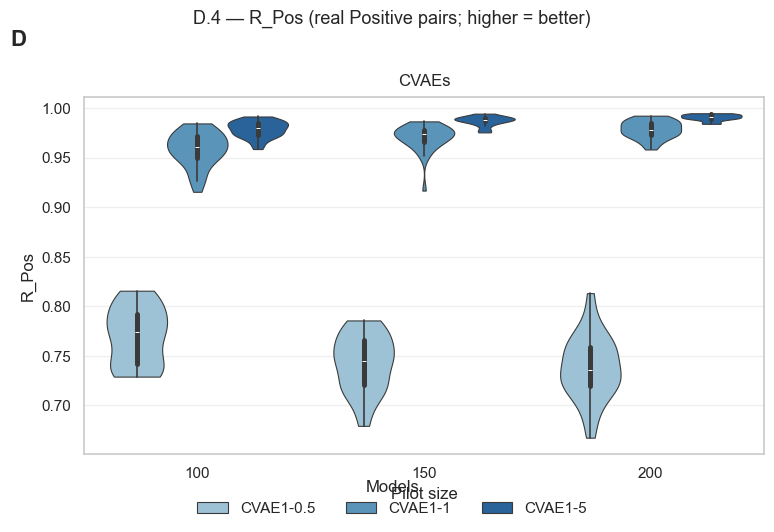

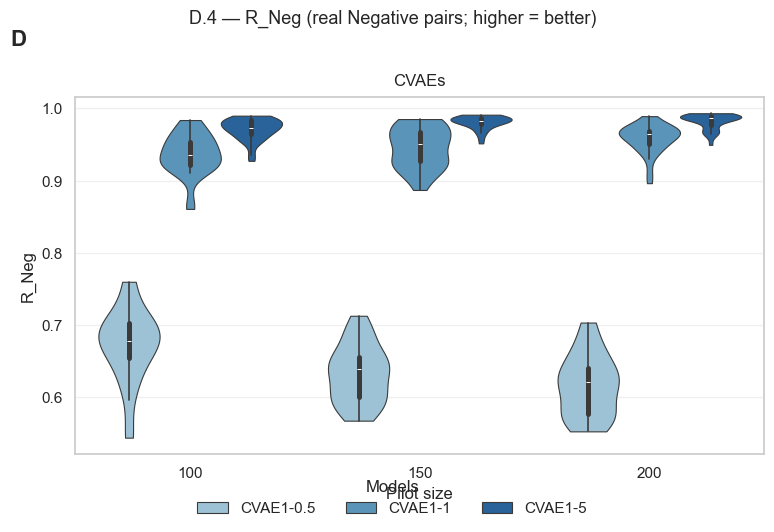

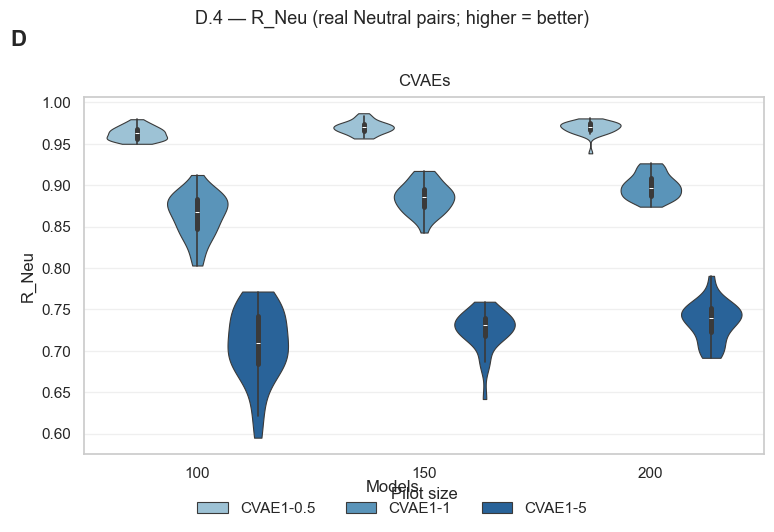

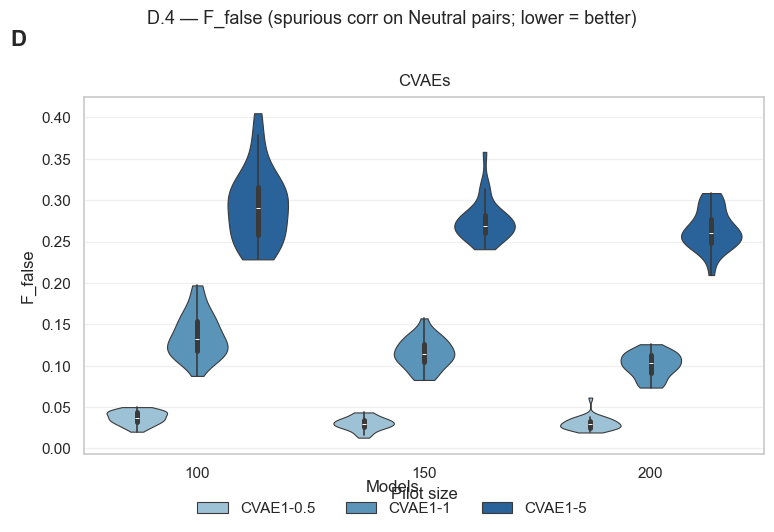

In [84]:
# Chunk 18 — D.4 Summary 1 violins (corr_5.4). Data from Chunk 16; 5 figures.

SUMMARY1_PLOT_SPECS = {
    "R_global": {
        "title": "D.4 — R_global (all pairs; higher = better)",
        "ylabel": "R_global",
    },
    "R_Pos": {
        "title": "D.4 — R_Pos (real Positive pairs; higher = better)",
        "ylabel": "R_Pos",
    },
    "R_Neg": {
        "title": "D.4 — R_Neg (real Negative pairs; higher = better)",
        "ylabel": "R_Neg",
    },
    "R_Neu": {
        "title": "D.4 — R_Neu (real Neutral pairs; higher = better)",
        "ylabel": "R_Neu",
    },
    "F_false": {
        "title": "D.4 — F_false (spurious corr on Neutral pairs; lower = better)",
        "ylabel": "F_false",
    },
}

for metric, spec in SUMMARY1_PLOT_SPECS.items():
    plot_pilot_violin_panel(
        summary1_draw_df,
        MODEL_FAMILIES,
        PILOT_SIZES,
        metric=metric,
        title=spec["title"],
        ylabel=spec["ylabel"],
        section_label="D",
    )